# Evolution Through the Transformer

**Previous:** [08_hooks](08_hooks.ipynb) (also fine after [03_residual_stream](03_residual_stream.ipynb) / [06_transformer_block](06_transformer_block.ipynb))  
**Home:** [../00_START_HERE.ipynb](../00_START_HERE.ipynb)  
**Next:** [02_observe/00_OVERVIEW](../02_observe/00_OVERVIEW.ipynb) · deeper intervene: [03_intervene](../03_intervene/00_OVERVIEW.ipynb)

**Kernel:** `CXR local Qwen (faiss_gpu1)`  
**Status:** executable

---

## 1. Why am I learning this?

Two different questions — do **not** collapse them:

| Half | Question | Tool |
|------|----------|------|
| **Observational** | Where does the A/B representation evolve? | layer sweep / `||A−B||` |
| **Causal** | Where can we change the answer? | intervene (zero / patch / steer) |

The sweep is **not** “find the layer with the biggest number.”  
It shows **how the representation develops through depth**. L20 often sits in a region where separation is already substantial — but **max `||A−B||` is usually late (e.g. L27)**, so size alone cannot pick L20.

Then we run a **causal layer sweep in this notebook** so L20 either **earns** the zoom from evidence here — or we follow whichever layer/site does.

Central lesson:

> **Representation strength ≠ causal importance**

## 2. Mental model — three rungs

```text
                 ALL 28 LAYERS
                       │
                       ▼
              ① MAGNITUDE SWEEP
                       │
             Where are writes large?
                       │
                       ▼
           ② REPRESENTATION SWEEP
                       │
          Where does A/B geometry emerge?
                       │
                       ▼
             ③ CAUSAL SWEEP (same notebook)
                       │
         MLP-zero / patch at L16…L27
                       │
                       ▼
             Does separation predict effect?
                       │
                       ▼
             Why zoom L20 — or not
```

## 3. Clinical question

On FOLFOX contrast prompts: how do magnitude and `||A−B||` evolve L0…L27, and does intervening at candidate layers (esp. MLP) change the answer more at L20 than at neighbors?

## 4. Prediction

`||A−B||` grows with depth (often largest near L27). Causal effect need **not** peak at the same layer. If they diverge, that is the lesson — not a failure.


## 5. Minimal Python — setup + load (run once)


In [32]:
# Shared bootstrap — run this first in every executable notebook
import sys
from pathlib import Path

# notebooks/_lib regardless of how deep this notebook sits
_here = Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "_lib" / "cxr_boot.py").is_file():
        sys.path.insert(0, str(_p / "_lib"))
        break
    if (_p / "notebooks" / "_lib" / "cxr_boot.py").is_file():
        sys.path.insert(0, str(_p / "notebooks" / "_lib"))
        break
else:
    raise RuntimeError("Cannot find notebooks/_lib/cxr_boot.py — open Jupyter with notebooks/ as root")

import cxr_boot
ctx = cxr_boot.setup(layer=20, max_new=24, load_model=True)
model, tok = ctx["model"], ctx["tok"]
NOTE, LAYER, MAX_NEW = ctx["NOTE"], ctx["LAYER"], ctx["MAX_NEW"]
PROMPT_A, PROMPT_B, PROMPT_TEST = ctx["PROMPT_A"], ctx["PROMPT_B"], ctx["PROMPT_TEST"]
look, intervene, process = ctx["look"], ctx["intervene"], ctx["process"]
print("NOTE:", NOTE)
print("LAYER:", LAYER, "(default zoom candidate — must earn via causal sweep below)")
print("n_layers:", len(model.model.layers))


BACKEND  REUSE — not calling from_pretrained; inspecting live weights
  pid=4097531  class=Qwen2ForCausalLM
  name=Qwen/Qwen2.5-7B-Instruct
  torch_dtype=torch.float16  training=False
  blocks=28  hidden=3584  using layer 20
  tokenizer=Qwen2TokenizerFast  vocab=151643  pad=151643  eos=151645
  hf_device_map (accelerate placement):
    model.embed_tokens: 0
    model.layers.0: 0
    model.layers.1: 0
    model.layers.2: 0
    model.layers.3: 0
    model.layers.4: 0
    model.layers.5: 0
    model.layers.6: 0
    model.layers.7: 0
    model.layers.8: 0
    model.layers.9: 0
    model.layers.10: 0
    model.layers.11: 0
    model.layers.12: 0
    model.layers.13: 0
    model.layers.14: 0
    model.layers.15: 0
    model.layers.16: 0
    model.layers.17: 0
    model.layers.18: 0
    model.layers.19: 0
    model.layers.20: 0
    model.layers.21: 0
    model.layers.22: 0
    model.layers.23: 0
    model.layers.24: 0
    model.layers.25: 0
    model.layers.26: 0
    model.layers.27: cpu
    

## 6a. Rung ① — print sites at every layer

Same camera as `look.py --mode sites`, but **all** blocks — not `(0, LAYER)`.


In [ ]:
# Print block / attn / mlp L2 at every layer (teaching note)
n = len(model.model.layers)
for layer in range(n):
    print(f"\n=== layer {layer} ===")
    look.cmd_sites(model, tok, layer=layer, text=NOTE)


## 6b. Full path table — one forward, hooks on every block

Capture at least:

```text
Layer | resid_in | attention | after_attn | MLP | resid_out
```

One forward with hooks on all 28 blocks (faster than 28 separate forwards).


In [33]:
# One forward → evolution table for last-token path through every block
from _common import blocks, unwrap, encode, device
import torch

ids = encode(tok, NOTE, device(model))
layer_list = blocks(model)
buckets = [{} for _ in layer_list]
handles = []

for i, block in enumerate(layer_list):
    def pre(_m, inp, i=i):
        hs = unwrap(inp[0] if isinstance(inp, tuple) else inp)
        buckets[i]["rin"] = hs[0, -1, :].detach().float().cpu()

    def attn_h(_m, _i, out, i=i):
        buckets[i]["attn"] = unwrap(out)[0, -1, :].detach().float().cpu()

    def mlp_h(_m, _i, out, i=i):
        buckets[i]["mlp"] = unwrap(out)[0, -1, :].detach().float().cpu()

    def post(_m, _i, out, i=i):
        buckets[i]["rout"] = unwrap(out)[0, -1, :].detach().float().cpu()

    handles.extend(
        [
            block.register_forward_pre_hook(pre),
            block.self_attn.register_forward_hook(attn_h),
            block.mlp.register_forward_hook(mlp_h),
            block.register_forward_hook(post),
        ]
    )

try:
    with torch.inference_mode():
        model(**ids)
finally:
    for h in handles:
        h.remove()

rows = []
print(f"{'L':>3}  {'resid_in':>10}  {'attention':>10}  {'after_attn':>10}  {'MLP':>10}  {'resid_out':>10}")
for i, b in enumerate(buckets):
    rin, attn, mlp, rout = b["rin"], b["attn"], b["mlp"], b["rout"]
    after = rin + attn
    row = {
        "layer": i,
        "resid_in": float(rin.norm()),
        "attention": float(attn.norm()),
        "after_attn": float(after.norm()),
        "MLP": float(mlp.norm()),
        "resid_out": float(rout.norm()),
        "add_check": float((rin + attn + mlp - rout).norm()),
    }
    rows.append(row)
    mark = "  ← CXR prior zoom" if i == LAYER else ""
    print(
        f"{i:3d}  {row['resid_in']:10.4f}  {row['attention']:10.4f}  "
        f"{row['after_attn']:10.4f}  {row['MLP']:10.4f}  {row['resid_out']:10.4f}{mark}"
    )

print("\nmax add_check (should be ~0):", max(r["add_check"] for r in rows))


  L    resid_in   attention  after_attn         MLP   resid_out
  0      0.8562      7.3859      7.4984      4.5926     10.4349
  1     10.4349      4.8409     11.9526      7.3823     16.8572
  2     16.8572      4.2065     16.7814      5.0395     19.6629
  3     19.6629      5.4327     19.1885      5.2301     19.0987
  4     19.0987      7.1434     21.4988      9.3611     24.2367
  5     24.2367      6.9177     25.3374     10.4054     28.9484
  6     28.9484     10.2210     33.7183     11.5614     33.1546
  7     33.1546     11.0166     35.5768     16.5204     37.1714
  8     37.1714     10.0106     39.5738     19.2524     44.3231
  9     44.3231     12.1666     44.1621     25.1868     49.6815
 10     49.6815      9.0699     50.9407     19.6557     49.6845
 11     49.6845     12.3555     53.7673     17.7187     52.8286
 12     52.8286      9.5859     52.0752     17.1211     52.9789
 13     52.9789     12.8321     55.2950     20.9311     60.8997
 14     60.8997     10.1027     60.1391 

## 6c. Turn the 28 measurements into curves

See computation develop through depth — residual / attention / MLP magnitude vs layer.


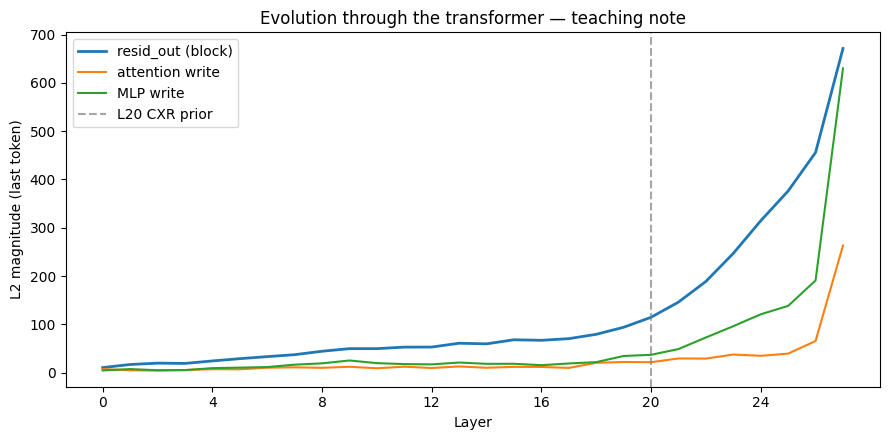

In [34]:
# Magnitude curves across depth
import matplotlib.pyplot as plt

layers = [r["layer"] for r in rows]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(layers, [r["resid_out"] for r in rows], label="resid_out (block)", linewidth=2)
ax.plot(layers, [r["attention"] for r in rows], label="attention write", linewidth=1.5)
ax.plot(layers, [r["MLP"] for r in rows], label="MLP write", linewidth=1.5)
ax.axvline(LAYER, color="gray", linestyle="--", alpha=0.7, label=f"L{LAYER} zoom candidate")
ax.set_xlabel("Layer")
ax.set_ylabel("L2 magnitude (last token)")
ax.set_title("Evolution through the transformer — teaching note")
ax.legend()
ax.set_xticks(range(0, len(layers), 4))
plt.tight_layout()
plt.show()


## 6d. Claim boundary after magnitude

If L20 MLP looks large, that only justifies:

> L20 has a relatively large MLP write on this note.

That is **rung 1**. It does **not** select L20 for zoom. Keep going to representation + causal.


## 7. Rung ② — representation sweep (where is the information?)

```text
1. REPRESENTATION SWEEP — WHERE IS THE INFORMATION?
───────────────────────────────────────────────────
L0 ───── L8 ───── L16 ── L20 ───── L24 ─── L27
                         ↑
                 not necessarily the maximum

Observation we expect:
A/B separation grows strongly with depth.
L20 is NOT selected because it has maximum ||A-B||.
```

Contrast: `PROMPT_A` (FOLFOX stopped) vs `PROMPT_B` (continues). Measure last-token residual `||h_A − h_B||` at every layer.


  L     ||A-B||     cos_A     cos_B
  0      0.8367   +0.0619   -0.0218
  1      0.9843   +0.1483   +0.0817
  2      1.2026   +0.0574   -0.0096
  3      1.4468   +0.0248   -0.0551
  4      2.6552   +0.0404   -0.0700
  5      3.2322   -0.0065   -0.1160
  6      3.2701   -0.0270   -0.1255
  7      4.0054   +0.0413   -0.0643
  8      4.8618   +0.1810   +0.0747
  9      5.3474   +0.1130   +0.0000
 10      5.4533   +0.0093   -0.0964
 11      6.7522   +0.0866   -0.0414
 12      8.0173   -0.0428   -0.1852
 13      8.8246   -0.1285   -0.2708
 14      8.5234   +0.0030   -0.1380
 15     10.0025   +0.0653   -0.0804
 16     11.4175   -0.0297   -0.1953
 17     12.4162   -0.0627   -0.2336
 18     15.0379   +0.0607   -0.1405
 19     19.8650   +0.0949   -0.1227
 20     27.1845   +0.1128   -0.1322  ← zoom-candidate
 21     31.7460   +0.1509   -0.0991
 22     41.8805   +0.1449   -0.1257
 23     54.0773   +0.0750   -0.2044
 24     63.5958   +0.1029   -0.1598
 25     73.9995   +0.0693   -0.1728
 26     91

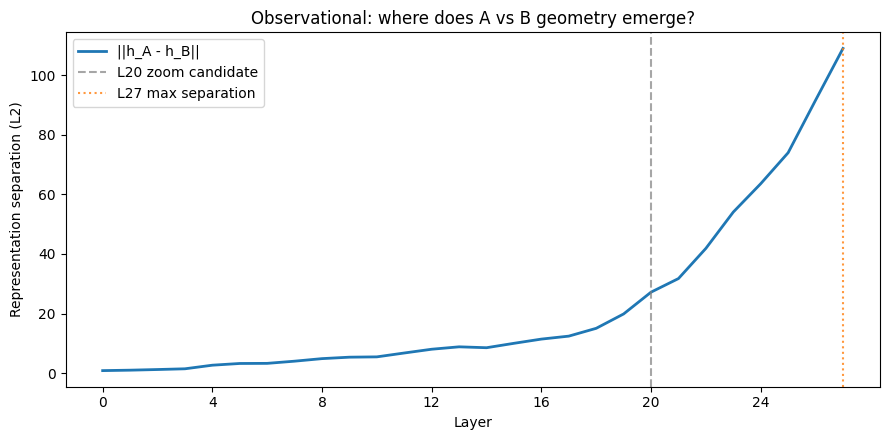

In [43]:
import matplotlib.pyplot as plt
# Representation separation: ||h_A - h_B|| vs layer (observational half)
from _common import last_residual, encode, device
import torch

dev = device(model)
ids_a = encode(tok, PROMPT_A, dev)
ids_b = encode(tok, PROMPT_B, dev)
n = len(model.model.layers)

sep_l2 = []
cos_a = []
cos_b = []
for layer in range(n):
    h_a = last_residual(model, ids_a, layer)
    h_b = last_residual(model, ids_b, layer)
    delta = h_a - h_b
    direction = delta / (delta.norm() + 1e-8)
    sep_l2.append(float(delta.norm()))
    cos_a.append(float(torch.dot(h_a / (h_a.norm() + 1e-8), direction)))
    cos_b.append(float(torch.dot(h_b / (h_b.norm() + 1e-8), direction)))

sep_by_layer = {i: sep_l2[i] for i in range(n)}
peak = max(range(n), key=lambda i: sep_l2[i])

print(f"{'L':>3}  {'||A-B||':>10}  {'cos_A':>8}  {'cos_B':>8}")
for i in range(n):
    tags = []
    if i == LAYER:
        tags.append("zoom-candidate")
    if i == peak:
        tags.append("MAX separation")
    mark = ("  ← " + ", ".join(tags)) if tags else ""
    print(f"{i:3d}  {sep_l2[i]:10.4f}  {cos_a[i]:+8.4f}  {cos_b[i]:+8.4f}{mark}")

print(f"\nMAX ||A-B|| at L{peak} = {sep_l2[peak]:.4f}  |  L{LAYER} = {sep_l2[LAYER]:.4f}")
print("If peak ≠ L20: that is expected — representation max ≠ zoom reason.")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(n), sep_l2, label="||h_A - h_B||", linewidth=2)
ax.axvline(LAYER, color="gray", linestyle="--", alpha=0.7, label=f"L{LAYER} zoom candidate")
ax.axvline(peak, color="C1", linestyle=":", alpha=0.8, label=f"L{peak} max separation")
ax.set_xlabel("Layer")
ax.set_ylabel("Representation separation (L2)")
ax.set_title("Observational: where does A vs B geometry emerge?")
ax.legend()
ax.set_xticks(range(0, n, 4))
plt.tight_layout()
plt.show()


## 8. Bridge — two localizations

```text
                         ↓

2. CAUSAL EVIDENCE — WHERE CAN WE CHANGE THE BEHAVIOR?
───────────────────────────────────────────────────────
                    candidate MLP writes
                           │
                     intervention
                           │
                           ▼
                    output / margin changes

Compare several layers. Do not assume L20 wins.

                         ↓

3. WHY WE ZOOM INTO L20 (only if evidence supports it)
───────────────────────────────────────────────────────
L20 is not "the layer where the representation is largest."

L20 earns a zoom if it is a strong causal intervention site
that also sits in the later-layer region where A/B geometry
is already strongly developed.

Sweep = representation localization.
Intervention = causal localization.
They need not peak at the same layer.
```


## 9. Rung ③ — causal layer sweep (MLP zero)

Same prompt (`PROMPT_TEST`). For each candidate layer: record base vs MLP-zero **next-token Yes−No logit margin** and short greedy string.

Ask:

> **Does increasing `||A−B||` predict increasing causal effect?**

If L27 has huge separation but weak Δmargin while L20 flips harder — boxed lesson:

**Representation strength ≠ causal importance.**


In [41]:
# Causal sweep: MLP last-token zero at candidate layers on PROMPT_TEST
# Requires: model/tok + sep_by_layer/peak from the representation cell above.
# Joins observational ||A-B|| with Δmargin / text flip.
from _common import encode, device, token_ids, blocks, module, unwrap, greedy
import torch

if "sep_by_layer" not in dir() or not sep_by_layer:
    raise RuntimeError(
        "sep_by_layer missing — run the representation sweep cell (§7) first on this same kernel."
    )

CANDIDATE_LAYERS = [16, 18, 20, 22, 24, 26, 27]
MAX_NEW_CAUSAL = min(MAX_NEW, 16)

dev = device(model)
ids_test = encode(tok, PROMPT_TEST, dev)
yes_ids = token_ids(tok, (" Yes", "Yes", " yes"))
no_ids = token_ids(tok, (" No", "No", " no"))


def yes_no_margin(logits: torch.Tensor) -> float:
    yes = max(float(logits[i]) for i in yes_ids)
    no = max(float(logits[i]) for i in no_ids)
    return yes - no


def next_logits(*, on_layer: int | None = None, zero_mlp: bool = False) -> torch.Tensor:
    handles = []
    if on_layer is not None and zero_mlp:
        def hook(_m, _inp, out):
            hs = unwrap(out)
            modified = hs.clone()
            modified[0, -1, :] = 0
            if isinstance(out, tuple):
                return (modified,) + out[1:]
            return modified

        handles.append(module(blocks(model)[on_layer], "mlp").register_forward_hook(hook))
    try:
        with torch.inference_mode():
            out = model(**ids_test)
        return out.logits[0, -1, :].detach().float().cpu()
    finally:
        for h in handles:
            h.remove()


base_logits = next_logits()
base_margin = yes_no_margin(base_logits)
base_text = greedy(model, tok, ids_test, MAX_NEW_CAUSAL)
print("PROMPT_TEST:", PROMPT_TEST)
print("BASE margin (Yes-No):", round(base_margin, 4))
print("BASE text:", repr(base_text))
print()

causal_rows = []
print(f"{'L':>3}  {'||A-B||':>8}  {'base_m':>8}  {'zero_m':>8}  {'Δmargin':>8}  flip  zero_text")
print("-" * 88)
for layer in CANDIDATE_LAYERS:
    z_logits = next_logits(on_layer=layer, zero_mlp=True)
    z_margin = yes_no_margin(z_logits)
    z_text = greedy(
        model, tok, ids_test, MAX_NEW_CAUSAL, on_layer=layer, site="mlp", zero_last=True
    )
    d_m = z_margin - base_margin
    flipped = z_text.strip() != base_text.strip()
    sep = float(sep_by_layer[layer])
    causal_rows.append(
        {
            "layer": layer,
            "sep": sep,
            "base_margin": base_margin,
            "zero_margin": z_margin,
            "delta_margin": d_m,
            "flip": flipped,
            "zero_text": z_text,
        }
    )
    print(
        f"{layer:3d}  {sep:8.2f}  {base_margin:8.3f}  {z_margin:8.3f}  {d_m:8.3f}  "
        f"{'Y' if flipped else 'n':>4}  {z_text!r}"
    )

assert causal_rows, "causal_rows empty — unexpected"

by_effect = sorted(causal_rows, key=lambda r: abs(r["delta_margin"]), reverse=True)
print("\nRanked by |Δmargin| (MLP zero):")
for r in by_effect:
    tag = "  ← LAYER default" if r["layer"] == LAYER else ""
    print(f"  L{r['layer']:2d}  |Δm|={abs(r['delta_margin']):.3f}  flip={r['flip']}{tag}")

best = by_effect[0]["layer"]
print(f"\nStrongest |Δmargin| among candidates: L{best}")
print(f"Max ||A-B|| among all layers was L{peak} — compare to L{best} / L{LAYER}.")
print(f"len(causal_rows)={len(causal_rows)} — ready for side-by-side plot cell")


PROMPT_TEST: Progress note: Oxaliplatin/5-FU course ended in March. Surveillance only. Has FOLFOX stopped? Answer yes or no.
BASE margin (Yes-No): -3.8125
BASE text: ' No. Based on the information provided, it seems that the patient has completed a'

  L   ||A-B||    base_m    zero_m   Δmargin  flip  zero_text
----------------------------------------------------------------------------------------
 16     11.42    -3.812    -3.078     0.734     Y  ' No. The patient is on a surveillance schedule after completing their oxaliplatin'
 18     15.04    -3.812    -2.828     0.984     n  ' No. Based on the information provided, it seems that the patient has completed a'
 20     27.18    -3.812    -2.047     1.766     Y  ' No. The patient is on a maintenance regimen of FOLFOX, which typically'
 22     41.88    -3.812    -2.688     1.125     n  ' No. Based on the information provided, it seems that the patient has completed a'
 24     63.60    -3.812    -3.969    -0.156     Y  ' NoWhat is the si

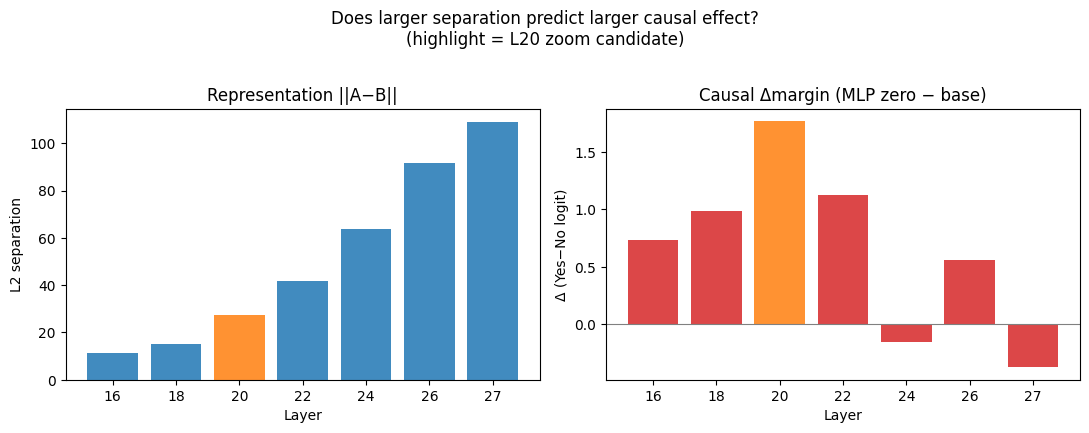

Fill after you look:
  Layer with max ||A-B|| among candidates: 27
  Layer with max |Δmargin|: 20
  Same layer? False
  → if NO, you have shown representation ≠ causation.
  → In this run, L20 earns the zoom on |Δmargin| (not on max separation).


In [42]:
# Side-by-side: representation vs causal effect at candidate layers
# Requires causal_rows from the causal sweep cell immediately above.
from IPython.display import display
import matplotlib.pyplot as plt

# Ensure figures render in Jupyter (avoid silent Agg / non-inline backends)
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

if "causal_rows" not in dir() or not causal_rows:
    raise RuntimeError(
        "causal_rows is empty/missing — run the causal sweep cell (§9) first on this same kernel "
        "(Connect to Existing 119f847c if you just opened the notebook)."
    )

xs = [r["layer"] for r in causal_rows]
xlabels = [str(x) for x in xs]
sep_vals = [r["sep"] for r in causal_rows]
dm_vals = [r["delta_margin"] for r in causal_rows]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

colors0 = ["C1" if x == LAYER else "C0" for x in xs]
axes[0].bar(xlabels, sep_vals, color=colors0, alpha=0.85)
axes[0].set_title("Representation ||A−B||")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("L2 separation")

colors1 = ["C1" if x == LAYER else "C3" for x in xs]
axes[1].bar(xlabels, dm_vals, color=colors1, alpha=0.85)
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_title("Causal Δmargin (MLP zero − base)")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Δ (Yes−No logit)")

fig.suptitle(
    "Does larger separation predict larger causal effect?\n"
    f"(highlight = L{LAYER} zoom candidate)",
    y=1.02,
)
fig.tight_layout()
display(fig)  # explicit — works even if plt.show() is a no-op
plt.close(fig)

max_sep_L = max(causal_rows, key=lambda r: r["sep"])["layer"]
max_dm_L = max(causal_rows, key=lambda r: abs(r["delta_margin"]))["layer"]
print("Fill after you look:")
print("  Layer with max ||A-B|| among candidates:", max_sep_L)
print("  Layer with max |Δmargin|:", max_dm_L)
print("  Same layer?", max_sep_L == max_dm_L)
print("  → if NO, you have shown representation ≠ causation.")
if max_dm_L == LAYER:
    print(f"  → In this run, L{LAYER} earns the zoom on |Δmargin| (not on max separation).")
else:
    print(f"  → In this run, follow L{max_dm_L} for |Δmargin|; do not defend L{LAYER} by default.")


## 10. Why reference L20 in the code?

```text
3. WHY WE ZOOM INTO L20
───────────────────────────────────────────────────────
L20 is not "the layer where the representation is largest."

Default LAYER=20 in cxr_boot / scripts is a *zoom candidate*
motivated by earlier CXR intervene interest in L20 MLP.

In THIS notebook, L20 keeps that role only if the causal
sweep above shows a strong effect relative to neighbors
while also sitting in the developed A/B region.

If another layer wins |Δmargin|, follow the evidence —
change zoom, don't defend the default.
```

Bootstrap still sets `layer=20` so experiments have a default camera. That is a **prior / convenience**, not a theorem. The tables above are the justification surface.

## 11. What did I learn? (fill after run)

- Max `||A−B||` layer: ___
- Strongest MLP-zero `|Δmargin|` among candidates: ___
- Did they match? ___
- Does L20 earn the zoom in *this* run? ___
- One sentence: Representation ≠ causation because: ___

## 12. Claim boundary

✓ Observational localization via L0…L27 magnitude + A/B separation.  
✓ Causal localization via MLP-zero Δmargin / text flip at candidate layers.  
✓ Explicit comparison: does separation predict causal effect?

✗ Max `||A−B||` ⇒ choose that layer for intervene.  
✗ “Prior CXR said L20” without reproducing a causal comparison here.  
✗ One run forever proves L20 for all prompts/tasks.

## 13. CXR connection

Track B prior: L20 MLP was an intervention site of interest. This lesson **re-tests** that prior against a small causal grid. Deeper modes (steer/patch/attn-zero) live in `03_intervene/` and `scripts/intervene.py`.

## 14. Revision notes

| Date | Change |
|------|--------|
| 2026-09-18 | First executable evolution lesson (magnitude + A/B; causation preview only) |
| 2026-09-18 | Added causal MLP-zero sweep + rep-vs-causal plots; L20 must earn zoom; central lesson representation ≠ causation |
